In [4]:
import os
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import tensorflow as tf
#libraries for building the model
from tensorflow.keras.layers import BatchNormalization, Conv2D,MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

## Multi Input CNN Architecture

#### In this setup, your RTX 3050 will process four parallel branches. Each branch extracts features from one stem, and then they are all "glued" together into a single brain.

In [2]:
# Load the bundle
data = np.load('indian_genre_multi_input_data.npz')

# Extract the arrays
X_vocal = data['vocal']
X_drums = data['drums']
X_bass  = data['bass']
X_other = data['other']
y       = data['labels']

print(f"Dataset loaded: {X_vocal.shape} aligned samples ready for training.")

Dataset loaded: (10198, 150, 150, 1) aligned samples ready for training.


### 3 way data split

In [5]:
# 1. Create a master index list based on the number of samples
indices = np.arange(X_vocal.shape[0])

# 2. First Split: Separate 80% for Training and 20% for (Val + Test)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

# 3. Second Split: Split the 20% into 10% Validation and 10% Testing
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=y[temp_idx])

# --- APPLY THE SPLIT TO ALL STEMS ---
# Training Set
X_train = [X_vocal[train_idx], X_drums[train_idx], X_bass[train_idx], X_other[train_idx]]
y_train = y[train_idx]

# Validation Set (Used during model.fit)
X_val = [X_vocal[val_idx], X_drums[val_idx], X_bass[val_idx], X_other[val_idx]]
y_val = y[val_idx]

# Test Set (Used only at the very end for final evaluation)
X_test = [X_vocal[test_idx], X_drums[test_idx], X_bass[test_idx], X_other[test_idx]]
y_test = y[test_idx]

print(f"Training samples:   {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Testing samples:    {len(test_idx)}")

#important stratify
# In Indian music datasets, some genres might have fewer songs than others. Using stratify=y ensures that your Train, Val, and Test sets
# all have the exact same percentage of Bollypop, Semiclassical, etc. This prevents the model from being biased toward a specific genre
# just because it saw it more during training.

#shuffle also during training process - true be defautl

Training samples:   8158
Validation samples: 1020
Testing samples:    1020


In [6]:
import gc

# 1. Delete the original massive arrays from the .npz load
# (Replace these names with the exact variables you used to load the data)
del X_vocal
del X_drums
del X_bass
del X_other
del y
# If you created a temporary index array, delete that too
del indices 

# 2. Force the Garbage Collector to reclaim the RAM
gc.collect()

print("Original arrays deleted. System RAM cleared for training.")

Original arrays deleted. System RAM cleared for training.


In [3]:
indices = np.arange(X_vocal.shape[0]) #making a list of indices for the vocals, drums, other and bass separation
print(indices)

train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

print(train_idx) # indices randomize automatically by the train test split

# here for example
X_vocal.shape[0] # total 10198 mels

# will pick mel by randomized indices calculated above like below:

print(X_vocal[train_idx])

# or

y[train_idx] # both the mel' and their label are still synchronized for all vocals, drums, others and bass
# cause the random generated indices are same for all stems

# Even though the indices are "shuffled" (e.g., instead of 0,1,2,3, they might be 45,12,802,3), the relative position is preserved across all your variables.

# If train_idx[0] is index 45:

# X_vocal[45] is the Vocal for Song X.

# X_drums[45] is the Drums for Song X.

# y[45] is the Label for Song X.

# Because you use the same 45 for every stem, the "Vocals" of Song X will never accidentally be paired with the "Drums" of Song Y.

[    0     1     2 ... 10195 10196 10197]
[8269 4343 4529 ... 2624 2170 8805]
[[[[-45.370888]
   [-57.583843]
   [-80.      ]
   ...
   [-80.      ]
   [-55.07819 ]
   [-38.343597]]

  [[-45.301964]
   [-57.549946]
   [-80.      ]
   ...
   [-80.      ]
   [-55.035908]
   [-38.3093  ]]

  [[-44.99895 ]
   [-57.26037 ]
   [-80.      ]
   ...
   [-80.      ]
   [-55.002438]
   [-38.260986]]

  ...

  [[-65.08043 ]
   [-72.705345]
   [-80.      ]
   ...
   [-52.393677]
   [-48.522816]
   [-46.676792]]

  [[-65.16758 ]
   [-72.80094 ]
   [-80.      ]
   ...
   [-61.897717]
   [-55.774338]
   [-51.93485 ]]

  [[-65.20015 ]
   [-72.65192 ]
   [-79.77755 ]
   ...
   [-80.      ]
   [-67.31238 ]
   [-54.402016]]]


 [[[-30.910355]
   [-30.910355]
   [-30.910355]
   ...
   [-30.910355]
   [-30.910355]
   [-30.910355]]

  [[-30.910355]
   [-30.910355]
   [-30.910355]
   ...
   [-30.910355]
   [-30.910355]
   [-30.910355]]

  [[-30.910355]
   [-30.910355]
   [-30.910355]
   ...
   [-30.910355]
  

array([4, 2, 2, ..., 1, 1, 4])

### Data Split Visualization or see how it got divided

In [9]:
print(X_train[0].shape, "80 percent of X_vocal") # shape of vocal  # Xtrain list of 4 stems each of 80% of total
print(X_train[1].shape, "80 percent of X_drums") # shape of drums
print(X_train[2].shape, "80 percent of X_bass" ) # shape of bass
print(X_train[3].shape, "80 percent of X_other") # shape of other
print(y_train.shape)

print()

print(X_val[0].shape) # shape of vocal  # # Xval list of 4 stems each of 20% of total
print(X_val[1].shape) # shape of drums
print(X_val[2].shape) # shape of bass
print(X_val[3].shape) # shape of other
print(y_val.shape)

print()

print(X_test[0].shape) # shape of vocal  # Xtest list of 4 stems each of 20% of total
print(X_test[1].shape) # shape of drums
print(X_test[2].shape) # shape of bass
print(X_test[3].shape) # shape of other
print(y_test.shape)


(8158, 150, 150, 1) 80 percent of X_vocal
(8158, 150, 150, 1) 80 percent of X_drums
(8158, 150, 150, 1) 80 percent of X_bass
(8158, 150, 150, 1) 80 percent of X_other
(8158,)

(1020, 150, 150, 1)
(1020, 150, 150, 1)
(1020, 150, 150, 1)
(1020, 150, 150, 1)
(1020,)

(1020, 150, 150, 1)
(1020, 150, 150, 1)
(1020, 150, 150, 1)
(1020, 150, 150, 1)
(1020,)


# Data Normalization

## 3. Important: Normalize Separately or Together?
There is a small but vital detail here: Do not normalize using the Global Max of all 4 stems.

The Reason: "Drums" and "Vocals" have very different physical properties. If you use one "Global Max," a quiet stem like "Bass" might end up scaled to 0.0 to 0.1, while "Vocals" get 0.0 to 1.0.

The Fix: My function above normalizes each stem independently. This ensures the "Drums" branch sees the full 0–1 range of drum energy, and the "Vocals" branch sees the full 0–1 range of vocal energy.

In [7]:
def normalize_stems(stem_list):
    normalized_list = []
    for stem_array in stem_list:
        # Get min and max for this specific stem batch
        min_val = np.min(stem_array)
        max_val = np.max(stem_array)
        
        # Scale to 0-1 range
        # Formula: (x - min) / (max - min)
        normalized_stem = (stem_array - min_val) / (max_val - min_val)
        normalized_list.append(normalized_stem)
        
    return normalized_list

# Apply to your split data
X_train_norm = normalize_stems(X_train)
X_val_norm   = normalize_stems(X_val)
X_test_norm  = normalize_stems(X_test)

print("Normalization complete. New range:", np.min(X_train_norm[0]), "to", np.max(X_train_norm[0]))

Normalization complete. New range: 0.0 to 1.0


In [8]:
# Add this inside your normalization function or right after
# Normalizing creates floats (decimal numbers). In NumPy, these are often float64 by default, which take up twice as much RAM as float32.
# The Optimization: Convert your normalized arrays to float32 immediately to save 50% of your VRAM.

X_train_norm = [s.astype('float32') for s in X_train_norm]
X_val_norm   = [s.astype('float32') for s in X_val_norm]
X_test_norm  = [s.astype('float32') for s in X_test_norm]   

#float 64 takes too much system can crash almost 100%

In [7]:
## Your Final Data CheckAt this point,
#  you have:Aligned stems.
# Shuffled and Stratified splits
# Normalized values ($0.0$ to $1.0$).
# Memory-optimized (float32).

In [12]:
### Not a number(NaN) or inf or -inf value check
def check_data_integrity(stem_list, names=["Vocal", "Drums", "Bass", "Other"]):
    for i, stem in enumerate(stem_list):
        has_nan = np.isnan(stem).any()
        has_inf = np.isinf(stem).any()
        
        print(f"--- {names[i]} Integrity ---")
        print(f"  Contains NaN: {has_nan}")
        print(f"  Contains Inf: {has_inf}")
        
        if has_nan or has_inf:
            print(f"  ⚠️ WARNING: {names[i]} stem has invalid values!")
        else:
            print(f"  ✅ {names[i]} stem is clean.")

# Run the check on your normalized training data
check_data_integrity(X_train_norm)

--- Vocal Integrity ---
  Contains NaN: False
  Contains Inf: False
  ✅ Vocal stem is clean.
--- Drums Integrity ---
  Contains NaN: False
  Contains Inf: False
  ✅ Drums stem is clean.
--- Bass Integrity ---
  Contains NaN: False
  Contains Inf: False
  ✅ Bass stem is clean.
--- Other Integrity ---
  Contains NaN: False
  Contains Inf: False
  ✅ Other stem is clean.


### 3. Final Step: One-Hot Encoding Labels

In [9]:
## 3. Final Step: One-Hot Encoding Labels
# Since you have 5 unique labels ([0, 1, 2, 3, 4]), you have two choices for your loss function:

# Sparse Categorical Crossentropy: Keep labels as integers (0, 1, 2...).

# Categorical Crossentropy: Convert labels to "One-Hot" vectors (e.g., [1, 0, 0, 0, 0]).

## Moving to Training
Now that your X_train, X_val, and X_test lists are ready, your data is officially "Clean." You have:

Aligned Stems (All 4 stems match the same 4 seconds).

Balanced Classes (Thanks to stratify=y).

No Ordering Bias (Thanks to the shuffle).

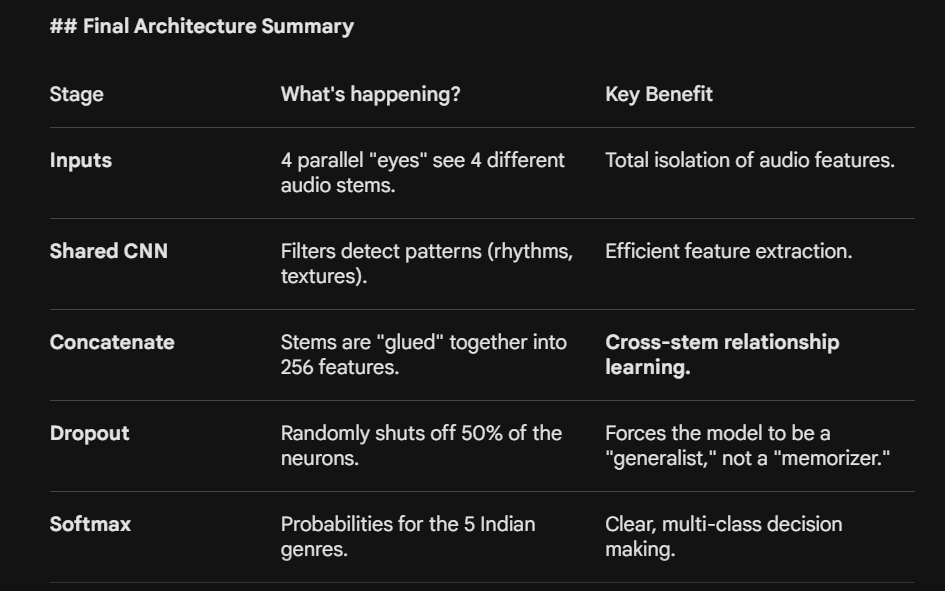

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_multi_input_model(input_shape=(150, 150, 1), num_classes=5, learning_rate = 0.0001):

    # 1. Define the 4 Inputs (Synchronized Tunnels)
    #input shape is given for feature extraction for each layers
    # isolated separate layer for each stem
    # each layer learn it's own features unaware of other
    #example : vocal spectrogram doesn't know anything about other , drum or bass except it's own features and patterns

    in_vocal = layers.Input(shape=input_shape, name="vocal_in")
    in_drum  = layers.Input(shape=input_shape, name="drum_in")
    in_bass  = layers.Input(shape=input_shape, name="bass_in")
    in_other = layers.Input(shape=input_shape, name="other_in")

    # 2. Optimized Feature Extractor (Mini-CNN) # also Functional Programming
    # Mini CNN runs on every stem
    # just consider it as a cnn layers a feature came like vocal
    # get extracted it's features by conv2d, max pool etc and returns the features
    # each features vocal, drum, bass and other get extracted here parallely and returned to variables 
    def extract_features(x):
        x = layers.Conv2D(filters= 32, kernel_size= (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x) # Helps with normalized data
        x = layers.MaxPool2D(pool_size = (2, 2), strides = 2)(x)
        
        x = layers.Conv2D(filters= 64, kernel_size= (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPool2D(pool_size = (2, 2), strides = 2)(x)

        x = layers.Conv2D(filters= 128, kernel_size= (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPool2D(pool_size = (2, 2), strides = 2)(x)

        x = layers.Dropout(0.3)(x)

        x = layers.GlobalAveragePooling2D()(x) # RAM efficient for RTX 3050 instead of flatten
        return x

    # 3. Process all 4 stems in parallel
    # same logic applied to each feature simultaneously.
    # now we have four different features vectors- list of numbers that different soul each stem
    v_feat = extract_features(in_vocal)
    d_feat = extract_features(in_drum)
    b_feat = extract_features(in_bass)
    o_feat = extract_features(in_other)

    # 4. Concatenate (Relationship Learning) , here all four stems learns thier realtionship
    # Total features: 128 * 4 = 512, 128 for each stem cuz above last conv2d layer has filter of 64
    # The model takes the four separate summaries and glues them together into one long list of 256 features (64 features×4 stems).
    # his is the Relationship Layer. Now, the model can "see" that a specific pattern in the Vocals is happening at the same time as a
    # specific pattern in the Drums. This is how it learns to identify Carnatic music (where the Vocals and Violin follow the same melody).

    merged = layers.Concatenate()([v_feat, d_feat, b_feat, o_feat])

    # 5. Final Classification Dense Layers which decides the final output
    # Dense(128): This is a fully connected layer that looks at all 256 merged features and tries to find the combination that points to a specific genre.
    x = layers.Dense(256, activation='relu')(merged)

    x = layers.Dropout(0.5)(x) # Prevents overfitting

    # Softmax: Since you have 5 genres, this layer outputs 5 probabilities (e.g., [0.90, 0.05, 0.02, 0.02, 0.01]). The highest number is your predicted genre!
    output = layers.Dense(num_classes, activation='softmax')(x) 




    # 1. In standard keras model(sequential) we just stack layers on top each other, now using keras funtional api
    # 2. hooks up all fours separate data into one model
    # 3. Input - in model.fit(X_train), X_train should have stem order exact same as here , vocal, drum, bass, other
    # 4. Output: 
    #This points to the very last layer of your network (the Softmax layer).
    # It tells the model: "After the data has traveled through the 4 branches, been merged, passed through Dropout," 
    # and reached the final 5 neurons—that is the final answer."
    # Because you defined num_classes=5, this output is a probability distribution (e.g., a 90% chance it's genre #2).
                                                                                  
    model = models.Model(inputs=[in_vocal, in_drum, in_bass, in_other], outputs=output)
    
    # Compile INSIDE using the provided learning rate
    model.compile(
        optimizer= Adam(learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [8]:
# Initialize the model
multi_model = build_multi_input_model(input_shape=(150, 150, 1), num_classes=5)
# multi_model.summary()

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Save only the BEST version of the model
checkpoint = ModelCheckpoint(
    'best_indian_genre_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max'
)

# 2. Stop early if accuracy stops improving (saves electricity and GPU life)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)
# 2. Lower learning rate if progress stalls (helps get that extra 2-3%)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=4, 
    min_lr=0.00001
)


callbacks_list = [checkpoint, early_stop, reduce_lr]

In [10]:
# Assuming X_train_norm is your list: [v_train, o_train, d_train, b_train]
history = multi_model.fit(
    x=X_train_norm,
    y=y_train,
    validation_data=(X_val_norm, y_val),
    epochs=50,
    batch_size=4, 
    callbacks=callbacks_list, # Make sure this includes your ModelCheckpoint
    verbose=1
)

# # Visualize the result
# plot_training_history(history)

Epoch 1/50
2040/2040 [==============================] - 56s 24ms/step - loss: 1.2926 - accuracy: 0.4722 - val_loss: 1.0167 - val_accuracy: 0.5951 - lr: 1.0000e-04
Epoch 2/50
2040/2040 [==============================] - 49s 24ms/step - loss: 1.0688 - accuracy: 0.5667 - val_loss: 0.9011 - val_accuracy: 0.6500 - lr: 1.0000e-04
Epoch 3/50
2040/2040 [==============================] - 48s 24ms/step - loss: 0.9624 - accuracy: 0.6172 - val_loss: 0.7644 - val_accuracy: 0.6931 - lr: 1.0000e-04
Epoch 4/50
2040/2040 [==============================] - 48s 24ms/step - loss: 0.8688 - accuracy: 0.6578 - val_loss: 0.8058 - val_accuracy: 0.6598 - lr: 1.0000e-04
Epoch 5/50
2040/2040 [==============================] - 49s 24ms/step - loss: 0.7920 - accuracy: 0.6899 - val_loss: 0.6875 - val_accuracy: 0.7108 - lr: 1.0000e-04
Epoch 6/50
2040/2040 [==============================] - 49s 24ms/step - loss: 0.7156 - accuracy: 0.7184 - val_loss: 0.6068 - val_accuracy: 0.7745 - lr: 1.0000e-04
Epoch 7/50
2040/2040 [

In [13]:
# Save in the modern Keras format
multi_model.save('Multi_input_CNN_v2.keras') 

In [14]:
# big float value error of lr in the last
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

# Now saving is a one-liner
with open('train_hist_Multi_input_CNN_v2.json', 'w') as f:
    json.dump(history.history, f, cls=NumpyEncoder, indent=4)

In [1]:
# One of the biggest reasons your file is so small is because you used Convolutional Layers and GlobalAveragePooling2D.

# If you had used only "Dense" (Fully Connected) layers for everything, your parameter count would be in the millions, and your file would be 100MB+.

### Model Evaluation

In [9]:
model = tf.keras.models.load_model("Multi_input_CNN_v2.keras")
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 vocal_in (InputLayer)          [(None, 150, 150, 1  0           []                               
                                )]                                                                
                                                                                                  
 drum_in (InputLayer)           [(None, 150, 150, 1  0           []                               
                                )]                                                                
                                                                                                  
 bass_in (InputLayer)           [(None, 150, 150, 1  0           []                               
                                )]                                                            

In [11]:
import json
with open('train_hist_Multi_input_CNN_v2.json', 'r') as json_file:
    training_history = json.load(json_file)

training_history.keys() #it is a dictionary now

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

## Evaluation on train and test data

In [13]:
training_loss ,training_accuracy = model.evaluate(X_test_norm, y_test)

32/32 [==============================] - 2s 52ms/step - loss: 0.0813 - accuracy: 0.9745


In [14]:
val_loss ,val_accuracy = model.evaluate(X_val_norm, y_val)

32/32 [==============================] - 2s 48ms/step - loss: 0.0874 - accuracy: 0.9706


In [15]:
test_loss ,test_accuracy = model.evaluate(X_test_norm, y_test)

32/32 [==============================] - 2s 48ms/step - loss: 0.0813 - accuracy: 0.9745


## Accuracy and loss visualization

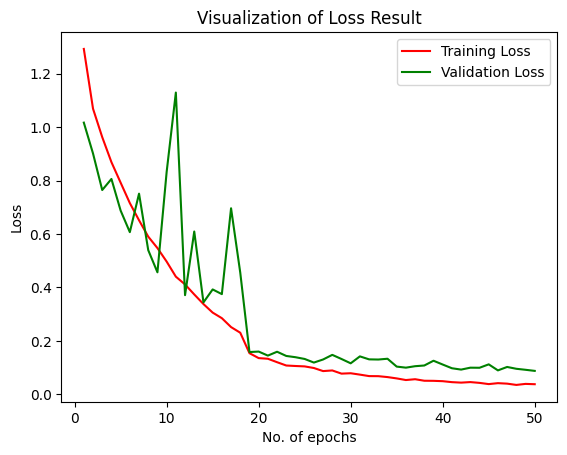

In [17]:
epochs = [i for i in range(1,51)]
plt.plot(epochs, training_history['loss'], label = 'Training Loss',color = 'red' ) 
plt.plot(epochs, training_history['val_loss'], label = 'Validation Loss',color = 'green' )
plt.xlabel('No. of epochs')
plt.ylabel('Loss')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

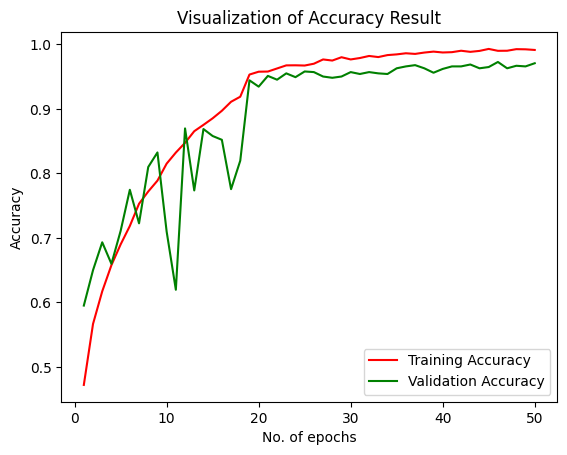

In [18]:
epochs = [i for i in range(1,51)]
plt.plot(epochs, training_history['accuracy'], label = 'Training Accuracy',color = 'red' ) 
plt.plot(epochs, training_history['val_accuracy'], label = 'Validation Accuracy',color = 'green' )
plt.xlabel('No. of epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Precision, Recall and Confusion Matrix

In [ ]:
#takes multiple inputs for test
# X_test = [X_vocal[test_idx], X_drums[test_idx], X_bass[test_idx], X_other[test_idx]]
# vocals, drums, bass and other all fours are required
y_pred = model.predict(X_test_norm)

#y_pred the predicted labels, y_test the actual labels
y_pred #probability out of 5 labels

32/32 [==============================] - 2s 48ms/step


array([[9.9969184e-01, 7.6317903e-08, 7.8432095e-06, 2.9963604e-04,
        6.2268339e-07],
       [9.9966645e-01, 1.0445107e-06, 1.0929944e-05, 1.6857767e-04,
        1.5299584e-04],
       [1.2869661e-02, 1.3676106e-03, 1.4405482e-06, 9.8205388e-01,
        3.7074767e-03],
       ...,
       [1.0918548e-05, 1.1095944e-04, 9.2127621e-06, 1.6513282e-03,
        9.9821752e-01],
       [3.8326853e-08, 9.4871548e-06, 2.9947343e-05, 7.9692880e-05,
        9.9988079e-01],
       [3.5934608e-02, 1.4263882e-04, 4.9638825e-06, 9.5363736e-01,
        1.0280373e-02]], dtype=float32)

In [31]:
print(X_test_norm[0].shape)
print(y_pred.shape)

# X_test has 4 input  vocal , drums, bass, other and y label as output for same timestamps

# 1 y pred gives 5 probabilites out of each one chunk of same timestamps of X_test

#look here vocal at 0 has 1020 mel so 1020 labels

#hence y pred has 1020 lists of 5 probabilites

(1020, 150, 150, 1)
(1020, 5)


In [32]:
print(y_pred.shape) #probability out of 5 labels
print(y_test.shape)

(1020, 5)
(1020,)


### Choosing the maximum probabilities out of 5 genres it predicted

In [34]:
# as they are index based so first probability is for bollypop 
# classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi'] same as classes
#               0            1          2            3            4

# here np.argmax chooses the index of max probability

predicted_categories = np.argmax(y_pred, axis = 1)
predicted_categories


# axis = 0
# predicted_categories = np.argmax(y_pred, axis = 0)
# predicted_categories

array([0, 0, 3, ..., 4, 4, 3], dtype=int64)

In [35]:
print(y_test)
print(predicted_categories)        #now we have both true and predicted labels in a single array

[0 0 3 ... 4 4 3]
[0 0 3 ... 4 4 3]


In [36]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(
    y_test,
    predicted_categories,
)

cm

array([[204,   0,   0,   3,   2],
       [  2, 191,   0,   0,   0],
       [  0,   0, 209,   0,   0],
       [  3,   2,   1, 196,   1],
       [  4,   3,   0,   5, 194]], dtype=int64)

In [37]:
classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi']

## Classification Report

In [38]:
print(classification_report(y_test, predicted_categories,target_names=classes))

               precision    recall  f1-score   support

     bollypop       0.96      0.98      0.97       209
     carnatic       0.97      0.99      0.98       193
       ghazal       1.00      1.00      1.00       209
semiclassical       0.96      0.97      0.96       203
         sufi       0.98      0.94      0.96       206

     accuracy                           0.97      1020
    macro avg       0.97      0.97      0.97      1020
 weighted avg       0.97      0.97      0.97      1020



## Confusion Matrix Visualization

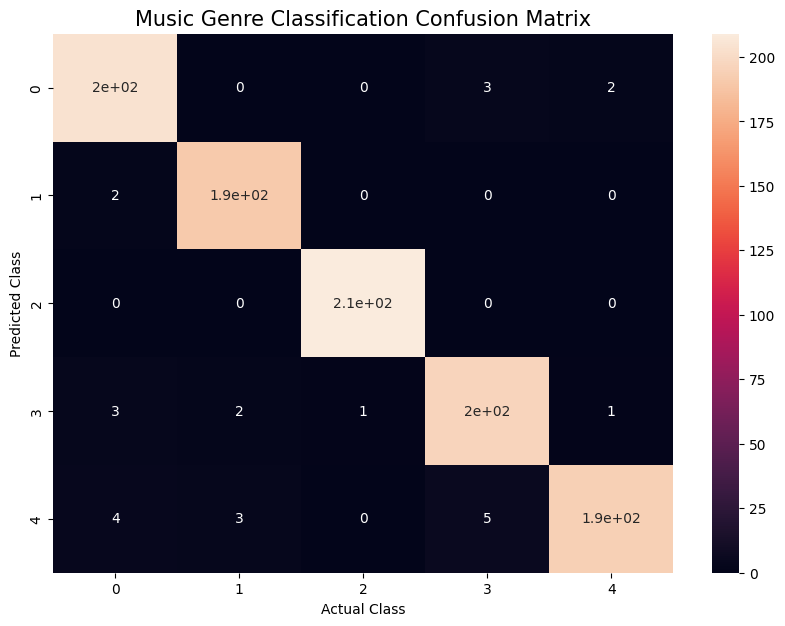

In [44]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,annot_kws={"size" : 10})
plt.ylabel("Predicted Class",fontsize=10)
plt.xlabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()